# Sensitivity Analysis

This notebook checks whether the descriptive findings from
`08_cross_event_analysis.ipynb` hold up when one specific assumption is
changed: the width of the event window. It builds three independent event-window
datasets -- +/-5 days, +/-7 days (the project's baseline), and +/-10 days -- and
compares them side by side.

**This is not causal inference.** No hypothesis test is run and no statistical
model is fit anywhere in this notebook. Every comparison below is a plain
descriptive statistic (mean, median, standard deviation, count) computed three
times, once per window width.

**Independent construction.** Per the brief, this notebook does **not** read
`data/processed/event_windows_master.csv`. All three windows are built directly
from `data/processed/station_daily_grap.csv` and
`data/raw/grap/grap_events_manual.csv`, using the same construction logic as
`06_event_window_construction.ipynb` but applied three times, once per window
width, entirely independently of each other and of any previously saved file.

> The notebook assumes it is run from the `notebooks/` folder, so the data paths
> below start with `../`. This notebook does not modify any earlier notebook.

# Setup

Load the two raw inputs and prepare the list of stations and verified events
that every window will be built from.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Input 1: the merged station-day dataset -- one row per station per day.
station_df = pd.read_csv('../data/processed/station_daily_grap.csv')
station_df['date'] = pd.to_datetime(station_df['date'])

# Input 2: the manually verified GRAP event calendar.
events_df = pd.read_csv('../data/raw/grap/grap_events_manual.csv')
events_df = events_df[events_df['verified'] == 'Yes'].copy()
events_df['effective_date'] = pd.to_datetime(events_df['effective_date'])

station_list = sorted(station_df['station_name'].unique())

print('Station-day rows:', len(station_df))
print('Verified events:', len(events_df))
print('Stations:', len(station_list))

Station-day rows: 5840
Verified events: 9
Stations: 8


**What this does.** Loads the station-day dataset and the verified GRAP event
calendar, converts their date columns to real dates, and lists the stations that
every window will include.

**Why this matters.** These two files are the only inputs used anywhere in this
notebook. Every one of the three windows built below is constructed from exactly
these rows -- nothing is read from a previously saved event-window file.

**How to read this.** Confirm 9 verified events and 8 stations before
continuing, matching the counts already established in earlier notebooks.

In [2]:
# A reusable function that builds one event-window dataset for a given
# half-width, entirely from the two inputs above. Increasing half_width simply
# widens the range of relative days included -- nothing else about the
# construction changes.
def build_event_window(half_width):
    rows = []
    for _, event_row in events_df.iterrows():
        event_id = event_row['event_id']
        event_date = event_row['effective_date']

        for relative_day in range(-half_width, half_width + 1):
            calendar_date = event_date + pd.Timedelta(days=relative_day)

            for station_name in station_list:
                rows.append({
                    'event_id': event_id,
                    'relative_day': relative_day,
                    'calendar_date': calendar_date,
                    'station_name': station_name,
                })

    skeleton = pd.DataFrame(rows)

    merged = skeleton.merge(
        station_df[[
            'station_name', 'date', 'pm25_ugm3', 'pm10_ugm3',
            'air_temp_c', 'rh_pct', 'wind_speed_ms'
        ]],
        left_on=['station_name', 'calendar_date'],
        right_on=['station_name', 'date'],
        how='left',
    )
    merged = merged.drop(columns=['date'])

    # Label each row as Pre, Event, or Post, the same way as the baseline
    # cross-event notebook.
    merged['period'] = 'Post'
    merged.loc[merged['relative_day'] < 0, 'period'] = 'Pre'
    merged.loc[merged['relative_day'] == 0, 'period'] = 'Event'

    return merged

**What this does.** Defines one function that builds a complete event-window
dataset for any half-width: it lays out the event x relative-day x station grid,
merges in the real PM2.5, PM10, temperature, humidity, and wind speed readings by
matching station and calendar date, and labels each row Pre, Event, or Post.

**Why this matters.** Using the same function for all three widths guarantees
that +/-5, +/-7, and +/-10 are built by identical logic. Any difference seen
later between the three windows is then a genuine consequence of window width,
not an artefact of three slightly different construction methods.

**How to read this.** This cell produces no output by itself; it is called three
times in Section 1 below.

# Section 1 -- Construct the Three Windows

Window A uses a +/-5 day event window, Window B uses the project's +/-7 day
baseline, and Window C uses a +/-10 day window. Each is built independently by
calling the function above with a different half-width.

In [3]:
window_a = build_event_window(5)   # +/-5 days
window_b = build_event_window(7)   # +/-7 days (baseline)
window_c = build_event_window(10)  # +/-10 days

print('Window A (+/-5 days):', len(window_a), 'rows,', window_a['relative_day'].nunique(), 'relative days')
print('Window B (+/-7 days):', len(window_b), 'rows,', window_b['relative_day'].nunique(), 'relative days')
print('Window C (+/-10 days):', len(window_c), 'rows,', window_c['relative_day'].nunique(), 'relative days')

Window A (+/-5 days): 792 rows, 11 relative days
Window B (+/-7 days): 1080 rows, 15 relative days
Window C (+/-10 days): 1512 rows, 21 relative days


**What this does.** Calls `build_event_window` three times with half-widths of
5, 7, and 10, producing three separate DataFrames, and prints each one's row
count and number of distinct relative days as a basic shape check.

**Why this matters.** Widening the window changes how many days contribute to
the Pre and Post periods (7 to 5, then 9, then 15, then 21 days per event once
both sides and the event day are counted), which is exactly the assumption this
notebook is testing the sensitivity of.

**How to read this.** Row counts should scale with window width: 9 events x 8
stations x (2 x half_width + 1) relative days -- 792 for Window A, 1,080 for
Window B, 1,512 for Window C.

# Section 2 -- PM2.5 Comparison Table

For each of the three windows, we compute the same descriptive statistics for
PM2.5 in the Pre period and the Post period, and gather all three windows into
one comparison table.

In [4]:
# One small helper: given a window DataFrame and a column, compute the Pre and
# Post descriptive statistics this notebook needs.
def summarize_window(window_df, column):
    pre_rows = window_df[window_df['period'] == 'Pre'][column]
    post_rows = window_df[window_df['period'] == 'Post'][column]

    return {
        'Total Rows': len(window_df),
        'Pre Mean': round(pre_rows.mean(), 2),
        'Post Mean': round(post_rows.mean(), 2),
        'Pre Median': round(pre_rows.median(), 2),
        'Post Median': round(post_rows.median(), 2),
        'Pre Std Dev': round(pre_rows.std(), 2),
        'Post Std Dev': round(post_rows.std(), 2),
        'Pre Count': pre_rows.count(),
        'Post Count': post_rows.count(),
    }

pm25_comparison = pd.DataFrame({
    'Window A (+/-5 days)': summarize_window(window_a, 'pm25_ugm3'),
    'Window B (+/-7 days)': summarize_window(window_b, 'pm25_ugm3'),
    'Window C (+/-10 days)': summarize_window(window_c, 'pm25_ugm3'),
}).T

pm25_comparison

,Total Rows,Pre Mean,Post Mean,Pre Median,Post Median,Pre Std Dev,Post Std Dev,Pre Count,Post Count
Window A (+/-5 days),792.0,189.39,168.48,189.70,164.30,80.86,86.20,360.0,360.0
Window B (+/-7 days),1080.0,184.67,167.05,189.14,162.12,79.45,84.67,502.0,504.0
Window C (+/-10 days),1512.0,175.42,165.61,184.16,159.76,83.07,84.31,715.0,720.0


**What this does.** Defines a helper that computes the mean, median, standard
deviation, and count of a given column separately for the Pre and Post rows of
one window, then applies it to PM2.5 for all three windows and combines the
results into a single table, one row per window.

**Why this matters.** This is the core sensitivity comparison for PM2.5: the
same Pre/Post descriptive statistics from the baseline cross-event notebook,
recomputed under a narrower and a wider window, side by side in one table.

**How to read this.** Compare each statistic down its column across the three
rows. A statistic that stays close across all three windows is one this
notebook's baseline finding does not depend heavily on; a statistic that shifts
noticeably as the window widens is one that does.

# Section 3 -- PM2.5 Profile Overlay

We now plot the mean PM2.5 profile (pooled across events and stations, by
relative day) for all three windows on the same axes.

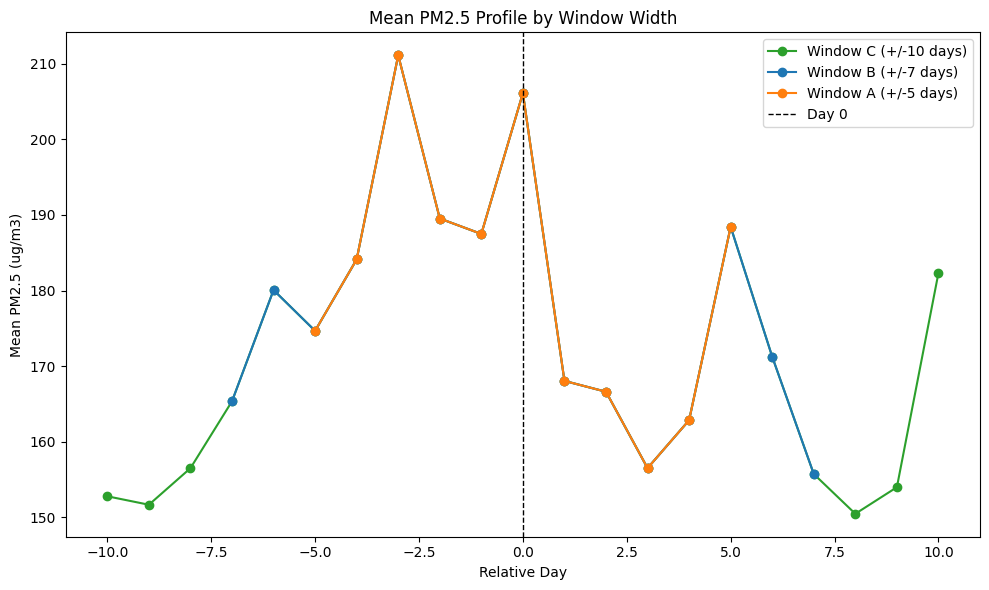

In [5]:
profile_a = window_a.groupby('relative_day')['pm25_ugm3'].mean()
profile_b = window_b.groupby('relative_day')['pm25_ugm3'].mean()
profile_c = window_c.groupby('relative_day')['pm25_ugm3'].mean()

plt.figure(figsize=(10, 6))
plt.plot(profile_c.index, profile_c.values, color='tab:green', marker='o', label='Window C (+/-10 days)')
plt.plot(profile_b.index, profile_b.values, color='tab:blue', marker='o', label='Window B (+/-7 days)')
plt.plot(profile_a.index, profile_a.values, color='tab:orange', marker='o', label='Window A (+/-5 days)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Day 0')

plt.title('Mean PM2.5 Profile by Window Width')
plt.xlabel('Relative Day')
plt.ylabel('Mean PM2.5 (ug/m3)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Computes the mean PM2.5 at each relative day, separately
for each of the three windows, and plots all three lines on one chart with a
dashed marker at Day 0. Window C is drawn first so the shorter Window A and
Window B lines are not hidden underneath it.

**Why this matters.** Because all three windows are built from the same events
and the same underlying station-day data, this chart shows directly whether the
extra days included by a wider window look like a continuation of the same
pattern, or something different.

**How to read this.** Look at whether the three lines sit on top of each other
over the relative days they all share, and how the longer lines (Window C, then
Window B) behave once they extend past where the shorter lines stop.

# Section 4 -- Weather Comparisons

The same Pre/Post comparison table and profile overlay are now repeated for
temperature, humidity, and wind speed.

In [6]:
temperature_comparison = pd.DataFrame({
    'Window A (+/-5 days)': summarize_window(window_a, 'air_temp_c'),
    'Window B (+/-7 days)': summarize_window(window_b, 'air_temp_c'),
    'Window C (+/-10 days)': summarize_window(window_c, 'air_temp_c'),
}).T

temperature_comparison

,Total Rows,Pre Mean,Post Mean,Pre Median,Post Median,Pre Std Dev,Post Std Dev,Pre Count,Post Count
Window A (+/-5 days),792.0,22.71,21.07,23.99,22.57,5.50,4.89,360.0,360.0
Window B (+/-7 days),1080.0,22.77,20.97,24.15,22.54,5.39,4.93,504.0,504.0
Window C (+/-10 days),1512.0,22.79,20.83,24.09,22.44,5.28,5.15,719.0,720.0


**What this does.** Applies the same `summarize_window` helper from Section 2
to temperature instead of PM2.5, for all three windows.

**Why this matters.** Temperature is a documented confounder in
`docs/analysis_plan.md`. Checking whether its Pre/Post pattern is also stable
across window widths is part of judging how much weight the PM2.5 comparison in
Section 2 can bear.

**How to read this.** Compare this table to the PM2.5 comparison table the same
way -- looking for which statistics move together across window widths and
which stay fixed.

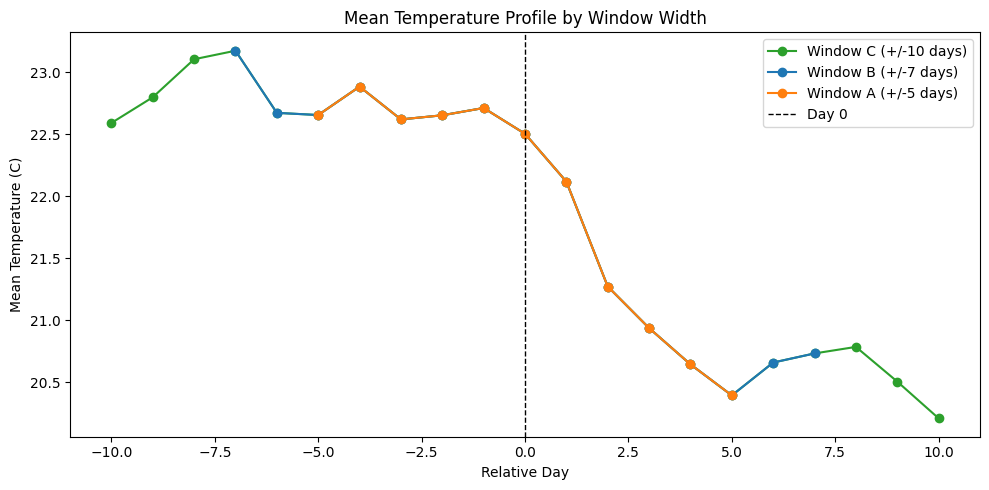

In [7]:
temp_profile_a = window_a.groupby('relative_day')['air_temp_c'].mean()
temp_profile_b = window_b.groupby('relative_day')['air_temp_c'].mean()
temp_profile_c = window_c.groupby('relative_day')['air_temp_c'].mean()

plt.figure(figsize=(10, 5))
plt.plot(temp_profile_c.index, temp_profile_c.values, color='tab:green', marker='o', label='Window C (+/-10 days)')
plt.plot(temp_profile_b.index, temp_profile_b.values, color='tab:blue', marker='o', label='Window B (+/-7 days)')
plt.plot(temp_profile_a.index, temp_profile_a.values, color='tab:orange', marker='o', label='Window A (+/-5 days)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Day 0')

plt.title('Mean Temperature Profile by Window Width')
plt.xlabel('Relative Day')
plt.ylabel('Mean Temperature (C)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean temperature at each relative day for all
three windows on one chart, built the same way as the PM2.5 overlay in
Section 3.

**Why this matters.** Placing this chart next to Section 3's PM2.5 overlay makes
it possible to see whether the two variables extend in a similar or a different
way once the window is widened.

**How to read this.** Read this chart the same way as Section 3 -- overlap on
shared days, and behaviour on the days only the wider windows include.

In [8]:
humidity_comparison = pd.DataFrame({
    'Window A (+/-5 days)': summarize_window(window_a, 'rh_pct'),
    'Window B (+/-7 days)': summarize_window(window_b, 'rh_pct'),
    'Window C (+/-10 days)': summarize_window(window_c, 'rh_pct'),
}).T

humidity_comparison

,Total Rows,Pre Mean,Post Mean,Pre Median,Post Median,Pre Std Dev,Post Std Dev,Pre Count,Post Count
Window A (+/-5 days),792.0,67.77,68.75,68.01,68.71,9.41,11.92,360.0,360.0
Window B (+/-7 days),1080.0,67.71,68.18,68.31,67.80,10.15,12.14,504.0,504.0
Window C (+/-10 days),1512.0,68.00,67.11,68.58,66.94,11.41,12.38,719.0,720.0


**What this does.** Applies `summarize_window` to humidity for all three
windows.

**Why this matters.** Humidity is the second weather confounder tracked
throughout this project; its Pre/Post pattern needs the same sensitivity check
as temperature and wind speed before any of them are read alongside the PM2.5
result.

**How to read this.** As with temperature, compare this table's Pre/Post gap
across the three window widths.

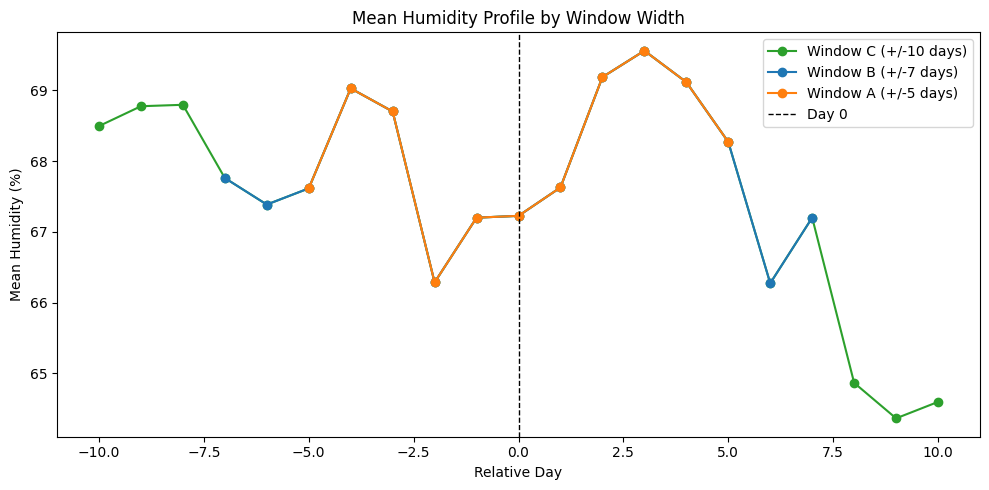

In [9]:
humidity_profile_a = window_a.groupby('relative_day')['rh_pct'].mean()
humidity_profile_b = window_b.groupby('relative_day')['rh_pct'].mean()
humidity_profile_c = window_c.groupby('relative_day')['rh_pct'].mean()

plt.figure(figsize=(10, 5))
plt.plot(humidity_profile_c.index, humidity_profile_c.values, color='tab:green', marker='o', label='Window C (+/-10 days)')
plt.plot(humidity_profile_b.index, humidity_profile_b.values, color='tab:blue', marker='o', label='Window B (+/-7 days)')
plt.plot(humidity_profile_a.index, humidity_profile_a.values, color='tab:orange', marker='o', label='Window A (+/-5 days)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Day 0')

plt.title('Mean Humidity Profile by Window Width')
plt.xlabel('Relative Day')
plt.ylabel('Mean Humidity (%)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean humidity at each relative day for all three
windows, built the same way as the two profile overlays above.

**Why this matters.** Humidity, unlike temperature, is bounded between 0% and
100%, so this chart also shows whether widening the window pulls the humidity
profile toward the middle of that range or leaves it where the narrower windows
had it.

**How to read this.** Read this chart the same way as the previous two overlay
charts.

In [10]:
wind_comparison = pd.DataFrame({
    'Window A (+/-5 days)': summarize_window(window_a, 'wind_speed_ms'),
    'Window B (+/-7 days)': summarize_window(window_b, 'wind_speed_ms'),
    'Window C (+/-10 days)': summarize_window(window_c, 'wind_speed_ms'),
}).T

wind_comparison

,Total Rows,Pre Mean,Post Mean,Pre Median,Post Median,Pre Std Dev,Post Std Dev,Pre Count,Post Count
Window A (+/-5 days),792.0,0.68,0.75,0.51,0.64,0.74,0.60,360.0,360.0
Window B (+/-7 days),1080.0,0.65,0.73,0.50,0.64,0.65,0.54,504.0,504.0
Window C (+/-10 days),1512.0,0.65,0.71,0.51,0.62,0.58,0.48,719.0,720.0


**What this does.** Applies `summarize_window` to wind speed for all three
windows, completing the set of three weather comparison tables.

**Why this matters.** Wind speed is the weather variable most directly tied to
pollutant dispersion; its sensitivity to window width closes out the same check
already run for temperature and humidity.

**How to read this.** Compare this table to the temperature and humidity tables
above, and to the PM2.5 table in Section 2 -- looking at all four together,
rather than any one in isolation.

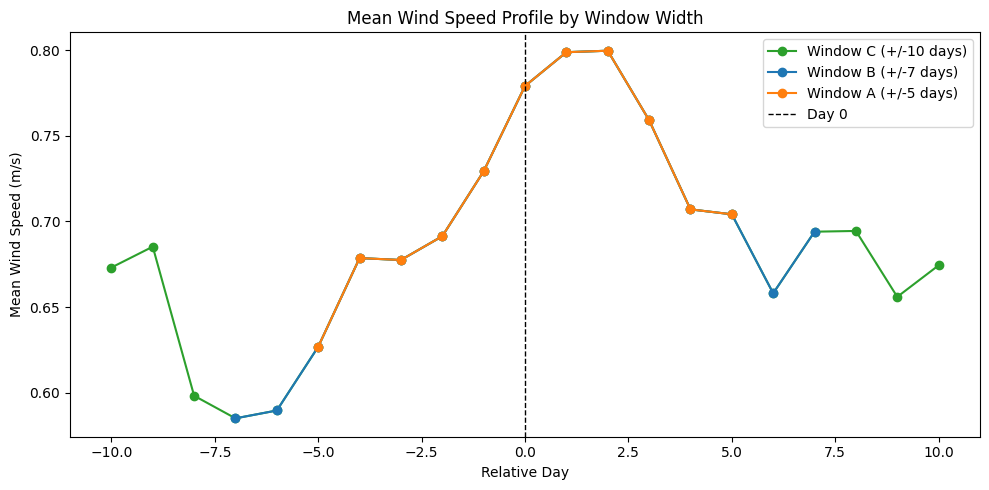

In [11]:
wind_profile_a = window_a.groupby('relative_day')['wind_speed_ms'].mean()
wind_profile_b = window_b.groupby('relative_day')['wind_speed_ms'].mean()
wind_profile_c = window_c.groupby('relative_day')['wind_speed_ms'].mean()

plt.figure(figsize=(10, 5))
plt.plot(wind_profile_c.index, wind_profile_c.values, color='tab:green', marker='o', label='Window C (+/-10 days)')
plt.plot(wind_profile_b.index, wind_profile_b.values, color='tab:blue', marker='o', label='Window B (+/-7 days)')
plt.plot(wind_profile_a.index, wind_profile_a.values, color='tab:orange', marker='o', label='Window A (+/-5 days)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Day 0')

plt.title('Mean Wind Speed Profile by Window Width')
plt.xlabel('Relative Day')
plt.ylabel('Mean Wind Speed (m/s)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean wind speed at each relative day for all
three windows, completing the four profile overlays (PM2.5, temperature,
humidity, wind speed).

**Why this matters.** With all four variables now checked the same way, the
question this notebook was built to answer -- does the +/-7 day baseline look
like an arbitrary cut, or a reasonable point on a stable pattern -- can be
answered from the same four charts together.

**How to read this.** Read this chart the same way as the previous three, then
step back and compare all four overlay charts as a set before moving to the
reflection and findings below.

# Section 5 -- Methodological Reflection

**Why sensitivity analysis is important.** Every descriptive number produced in
`08_cross_event_analysis.ipynb` depended on one specific choice: a +/-7 day
event window, justified in `docs/analysis_plan.md` as a balance between having
enough days to average over and staying short relative to the seasonal cycle.
A single choice is still a choice, and a reader has no way to know from that one
number alone whether a different, equally defensible choice would have told a
noticeably different story. Sensitivity analysis exists to answer exactly that,
by deliberately re-running the same descriptive computation under different
versions of the assumption in question.

**Why changing analytical assumptions matters.** The Pre and Post periods used
throughout this project are defined entirely by the window width: a wider
window does not change any single day's reading, but it does change which days
are pooled into "Pre" and "Post," and therefore what the pooled mean and median
represent. Testing +/-5 and +/-10 alongside the +/-7 baseline makes that
dependency visible instead of leaving it implicit in a single, unexamined
number.

**Why consistent findings increase confidence.** If a pattern -- for example,
the direction of the Pre-to-Post change -- holds up whether the window is
narrower or wider than the baseline, that pattern is less likely to be a
byproduct of exactly where the baseline happened to draw its cutoff. Consistency
across Window A, B, and C is not proof of anything causal, but it does mean the
descriptive picture in the baseline notebook is not fragile to this particular
choice.

**Why inconsistent findings should be reported honestly.** If a statistic shifts
noticeably between Window A, B, and C -- as several of the tables above do, in
magnitude if not in direction -- that shift is itself a finding, and hiding it
by only ever showing the baseline window would misrepresent how settled the
underlying picture actually is. Reporting the shift alongside the baseline
number, as this notebook does, is what keeps the project's claims no larger than
the evidence supports.

# Section 6 -- Findings

The statements below describe only what the tables and charts in Sections 2-4
show. None of them are the result of a statistical test, and none should be read
as evidence of what caused any pattern described.

**The direction of the PM2.5 Pre-to-Post difference is consistent across all
three windows.** The pooled Pre-period mean PM2.5 is higher than the pooled
Post-period mean in Window A (about 189 vs. 168 ug/m3), Window B (about 185 vs.
167 ug/m3), and Window C (about 175 vs. 166 ug/m3). The median shows the same
direction in all three windows.

**The size of that PM2.5 difference shrinks as the window widens.** The gap
between the Pre and Post means is about 21 ug/m3 in Window A, about 18 ug/m3 in
Window B, and about 10 ug/m3 in Window C. The direction does not change, but the
magnitude is not stable -- the wider the window, the smaller the pooled Pre/Post
gap.

**The mean PM2.5 profile is identical across windows on the days they share, and
only diverges by definition on the days a narrower window does not include.**
The Section 3 overlay chart shows the three lines sitting exactly on top of each
other over relative days -5 to +5, which all three windows share, since that
overlap is built from the same underlying rows in every window. Window B and
Window C extend that same line outward using additional relative days (+/-6 and
+/-7 for B; +/-6 through +/-10 for C) that Window A does not include at all.
This is also why the Pre/Post means shift with window width even though no
individual day's value changes: a wider window pools in additional, more distant
days alongside the same close-in days every window shares.

**Temperature shows the same consistent direction as PM2.5 across all three
windows** -- the Pre-period mean is higher than the Post-period mean in Window A,
B, and C alike -- though unlike PM2.5, the gap widens slightly rather than
narrowing as the window widens (about 1.6 C in Window A, about 1.8 C in Window B,
about 2.0 C in Window C). **Wind speed also shows a
consistent direction across all three windows**, with the Post-period mean
higher than the Pre-period mean each time. **Humidity shows a small, consistent
direction as well** (Post-period mean modestly higher than Pre-period mean in
Window A and B; the reverse, modestly, in Window C), though the gap in every
window is small relative to humidity's overall spread.

**Missing data increases slightly with window width.** Window C, the widest
window, has a small number of additional missing PM2.5, PM10, and weather
readings compared to Window A and Window B, consistent with a wider window
reaching into a few additional calendar dates with sparser station coverage.
The effect on the reported counts is minor in all three windows.

# Questions for Future Work

1. Does the narrowing Pre/Post PM2.5 gap seen from Window A to Window C continue
   to shrink at even wider windows (for example, +/-14 days), or does it
   stabilize or reverse beyond +/-10?
2. Is the shrinking gap better explained by the additional far-out days
   regressing toward a seasonal baseline, or by those days simply adding more
   noise (a larger standard deviation) without changing the average very much?
3. Does the same window-width sensitivity check, run separately per station
   rather than pooled city-wide, show the same consistent direction for every
   station, or does it vary?
4. Does the same check, run separately per event rather than pooled across all
   nine, show the same narrowing pattern for every event, or only for some?
5. Would an intermediate window width (for example, +/-6, +/-8, or +/-9 days)
   fall smoothly between the Window A, B, and C results shown here, or reveal a
   less gradual transition?
6. Temperature's Pre/Post gap narrows with window width in a similar way to
   PM2.5's -- is that a coincidence of the same calendar period, or does it hold
   for temperature independent of which events are included?
7. How would this sensitivity check look if it were repeated once a second
   GRAP season's verified events become available, as noted under Future
   Improvements in `docs/analysis_plan.md`?

*End of the Sensitivity Analysis notebook.*